# House Prices Prediction using Advanced Regression & Neural Networks
### 5th Semester IT Engineering — Data Science Project

**Project Objective:**
The objective of this project is to predict residential house sale prices in Ames, Iowa, using the Kaggle House Prices dataset. We implement a complete machine learning pipeline in Python, comparing an L1-regularized linear model (**Lasso Regression**) with a Deep Learning model (**Artificial Neural Network / MLPRegressor**).

**Key Concepts Covered:**
1. **Exploratory Data Analysis (EDA):** Checking feature distributions, correlation analysis, missing value detection, and target variable transformation.
2. **Data Preprocessing & Cleaning:** Handling missing data using median/most-frequent strategies, scaling numerical features, and encoding categorical variables using One-Hot Encoding via Scikit-Learn's `Pipeline` and `ColumnTransformer` (`sparse_output=False` for dense compatibility with neural networks).
3. **Model Development:**
   - **Lasso Regression (L1 Regularization):** Linear model with feature selection capability.
   - **Artificial Neural Network (ANN - MLPRegressor):** Multi-layer perceptron with 3 hidden layers (128 -> 64 -> 32 neurons) and ReLU activations.
4. **Fair Model Evaluation:** Evaluating both models under identical train/validation splits (80/20) and target transformations using Log-RMSE (Kaggle metric), original dollar scale RMSE, and $R^2$ score.
5. **Visualizations:** Comprehensive comparative plots including Actual vs Predicted, Residual distributions, and performance bar charts.
6. **Model Persistence & Submission:** Saving trained models (`best_house_price_model.pkl`, `ann_house_price_model.pkl`) and generating competition predictions (`submission.csv`).

## 1. Import Libraries
In this section, we import all necessary Python libraries for data processing, statistical visualization, machine learning, and neural network modeling.
- **Pandas & NumPy** for data manipulation and array computation.
- **Matplotlib & Seaborn** for professional statistical visualizations.
- **Scikit-Learn** for preprocessing pipelines, Lasso Regression, MLPRegressor (ANN), and evaluation metrics.

In [1]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Import scikit-learn preprocessing and pipeline tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import regression models (Lasso and MLPRegressor/ANN)
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style and figures parameters for professional aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset
We load the Ames Housing dataset from the local `data/` directory.
- `train.csv` contains 1,460 records with 79 features and the target variable `SalePrice`.
- `test.csv` contains 1,459 records for which we will predict the house prices.

In [2]:
# Define path to the datasets
train_path = 'data/train.csv'
test_path = 'data/test.csv'

# Verify files exist
if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Make sure train.csv and test.csv are located in the local 'data/' folder.")

# Load the datasets using pandas
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Display dataset dimensions (shapes)
print(f"Training dataset shape: {train.shape} (rows, columns)")
print(f"Testing dataset shape:  {test.shape} (rows, columns)")

# Preview the first 5 rows of the training dataset
train.head()

Training dataset shape: (1460, 81) (rows, columns)
Testing dataset shape:  (1459, 80) (rows, columns)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)
Exploratory Data Analysis helps us understand the structure, distributions, missing values, and correlations within the dataset.

Key steps:
1. Examine dataset types and missing value counts.
2. Analyze descriptive statistics.
3. Visualize `SalePrice` distribution (raw vs. log-transformed).
4. Generate a correlation heatmap of the top numerical features with `SalePrice`.
5. Assess feature skewness.

In [3]:
# 3.1 Display dataset structure and column data types
print("=== Training Dataset Info ===")
train.info()

=== Training Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 no

In [4]:
# 3.2 Calculate missing value percentage per column
missing_counts = train.isnull().sum()
missing_percent = 100 * train.isnull().sum() / len(train)

missing_data = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percent
})

missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(f"Total columns with missing values: {len(missing_data)}")
print("\nTop 15 columns with most missing values:")
print(missing_data.head(15))

Total columns with missing values: 19

Top 15 columns with most missing values:
              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtFinType2             38        2.602740
BsmtExposure             38        2.602740
BsmtFinType1             37        2.534247


In [5]:
# 3.3 Summary statistics of numerical columns
print("=== Descriptive Statistics for Numerical Features ===")
train.describe()

=== Descriptive Statistics for Numerical Features ===


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


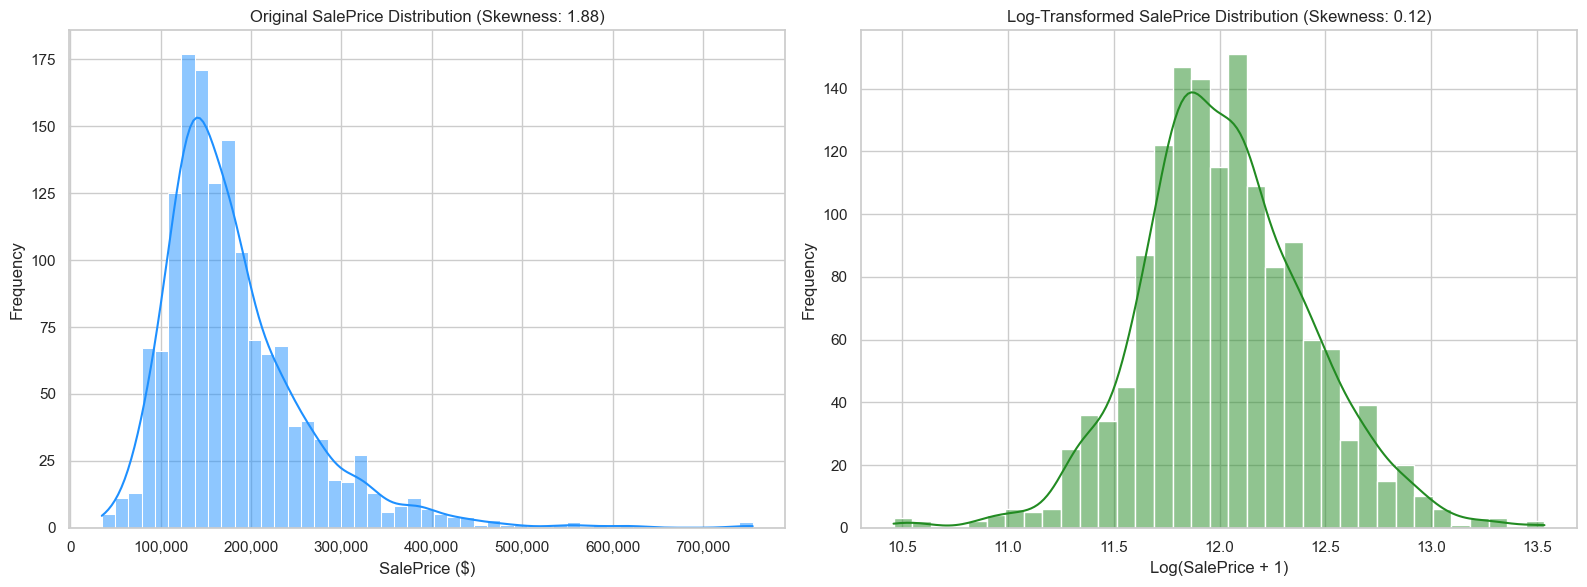

In [6]:
# 3.4 Visualize target variable SalePrice distribution (Original vs Log-Transformed)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw SalePrice distribution
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title(f"Original SalePrice Distribution (Skewness: {train['SalePrice'].skew():.2f})", fontsize=12)
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Frequency")
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Plot 2: Log-transformed SalePrice distribution (y = log(1 + x))
log_saleprice = np.log1p(train['SalePrice'])
sns.histplot(log_saleprice, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f"Log-Transformed SalePrice Distribution (Skewness: {log_saleprice.skew():.2f})", fontsize=12)
axes[1].set_xlabel("Log(SalePrice + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

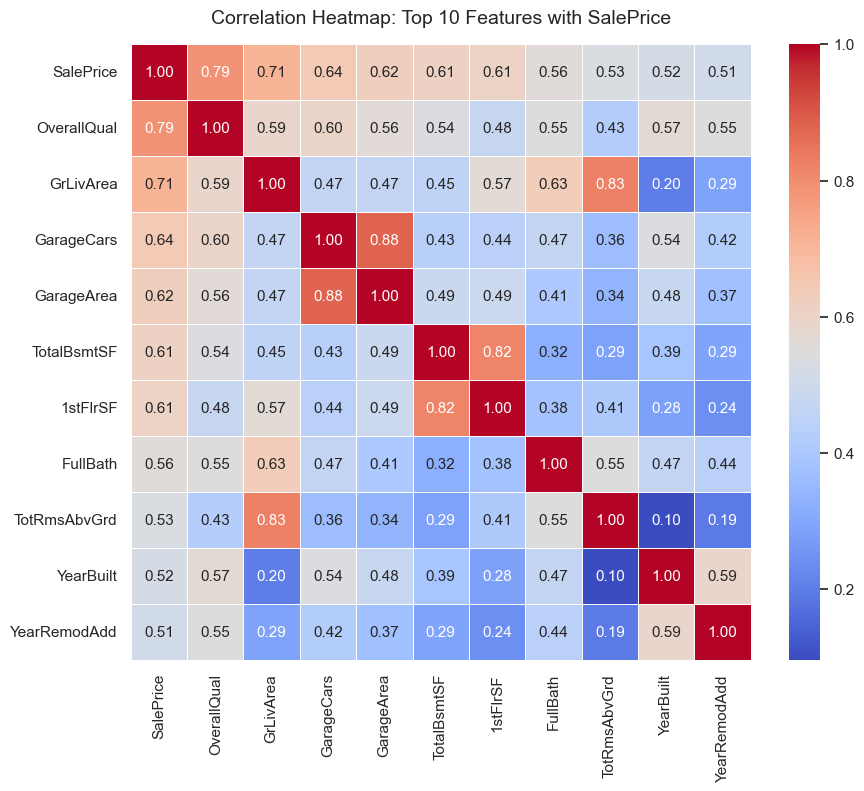

Top 10 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [7]:
# 3.5 Generate a correlation heatmap of numerical features
numerical_df = train.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Find top 10 features most correlated with SalePrice
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index[:11]

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title("Correlation Heatmap: Top 10 Features with SalePrice", fontsize=14, pad=15)
plt.show()

print("Top 10 features correlated with SalePrice:")
print(corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11))

In [8]:
# 3.6 Check skewness of numerical features
skewed_features = numerical_df.drop(columns=['Id', 'SalePrice']).skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({'Feature Skewness': skewed_features})
highly_skewed = skewness_df[abs(skewness_df['Feature Skewness']) > 0.75]

print(f"Total numerical features: {skewness_df.shape[0]}")
print(f"Highly skewed numerical features (|Skewness| > 0.75): {highly_skewed.shape[0]}")
print("\nTop 10 most positively skewed numerical features:")
print(highly_skewed.head(10))

Total numerical features: 36
Highly skewed numerical features (|Skewness| > 0.75): 21

Top 10 most positively skewed numerical features:
               Feature Skewness
MiscVal               24.476794
PoolArea              14.828374
LotArea               12.207688
3SsnPorch             10.304342
LowQualFinSF           9.011341
KitchenAbvGr           4.488397
BsmtFinSF2             4.255261
ScreenPorch            4.122214
BsmtHalfBath           4.103403
EnclosedPorch          3.089872


## 4. Data Preprocessing & Pipeline Construction
Both Lasso Regression and Artificial Neural Networks require numerical, well-scaled inputs without missing values.

### Preprocessing Architecture:
- **Numerical Pipeline:**
  - **SimpleImputer(strategy='median')**: Imputes missing values using the median to stay robust against outliers.
  - **StandardScaler()**: Normalizes features to have zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$). Crucial for gradient-based optimizers (Adam) in ANN and penalty balancing in Lasso.
- **Categorical Pipeline:**
  - **SimpleImputer(strategy='most_frequent')**: Fills missing categories with the column mode.
  - **OneHotEncoder(handle_unknown='ignore', sparse_output=False)**: Encodes categorical variables as dense one-hot vectors, ensuring compatibility with `MLPRegressor` and preventing sparse matrix issues.
- **ColumnTransformer**: Combines both pipelines into a single unified transformer.

In [9]:
# Separate predictor features (X) and target variable (y)
X = train.drop(columns=['Id', 'SalePrice'])
y = train['SalePrice']

# Extract predictor features for the test set
X_test = test.drop(columns=['Id'])

# Identify numerical and categorical column names
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Define Preprocessing Pipelines
# 1. Numerical pipeline (Median Imputation + Standard Scaling)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical pipeline (Most-Frequent Imputation + One-Hot Encoding)
# Using sparse_output=False for dense representation compatible with MLPRegressor
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine both preprocessors into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

print("Preprocessing pipelines successfully created!")
print(f"Number of numerical columns:   {len(numerical_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

Preprocessing pipelines successfully created!
Number of numerical columns:   36
Number of categorical columns: 43


## 5. Target Transformation & Train/Validation Split
To ensure a strictly fair comparison between Lasso and ANN:
1. **Target Log Transformation:** We compute $y_{log} = \log(1 + y)$ using `np.log1p()`.
2. **Consistent Split:** We use an 80% train and 20% validation split with `random_state=42`.
3. Both models are trained on the exact same $(X_{train}, y_{train})$ and evaluated on the exact same $(X_{val}, y_{val})$.

In [10]:
# Apply log transformation to the target variable
y_log = np.log1p(y)

# Perform 80/20 train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=42)

print(f"Training set features shape:   {X_train.shape}")
print(f"Validation set features shape: {X_val.shape}")
print(f"Target log-mean (Train):       {y_train.mean():.4f}")
print(f"Target log-mean (Val):         {y_val.mean():.4f}")

Training set features shape:   (1168, 79)
Validation set features shape: (292, 79)
Target log-mean (Train):       12.0307
Target log-mean (Val):         11.9977


## 6. Model 1: Lasso Regression (L1 Regularization)
Lasso (Least Absolute Shrinkage and Selection Operator) minimizes the residual sum of squares subject to an L1-penalty on coefficients:
$$\text{Loss} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |w_j|$$
- **Feature Selection:** Due to the geometric shape of the L1 diamond constraint, it forces less informative feature weights to exactly zero.
- **Configuration:** $\alpha = 0.0005$, `max_iter=10000`, `random_state=42`.

In [11]:
# Build the Lasso pipeline
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.0005, max_iter=10000, random_state=42))
])

print("Training Lasso Regression model...")
lasso_pipeline.fit(X_train, y_train)
print("Lasso Regression model trained successfully!")

Training Lasso Regression model...
Lasso Regression model trained successfully!


## 7. Model 2: Artificial Neural Network (MLPRegressor)
We implement an Artificial Neural Network using Scikit-Learn's `MLPRegressor`.

### Neural Network Architecture:
```text
  Input Layer (~288 Encoded Features)
               ↓
  Hidden Layer 1 (128 neurons, ReLU)
               ↓
  Hidden Layer 2 (64 neurons, ReLU)
               ↓
  Hidden Layer 3 (32 neurons, ReLU)
               ↓
  Output Layer   (1 continuous neuron for log-price)
```

### Hyperparameters:
- `hidden_layer_sizes=(128, 64, 32)`: Three fully connected hidden layers.
- `activation='relu'`: Rectified Linear Unit ($f(x) = \max(0, x)$) allowing the network to capture complex non-linear feature interactions.
- `solver='adam'`: Adaptive Moment Estimation optimizer for efficient stochastic gradient descent.
- `learning_rate_init=0.001`: Initial step size for Adam.
- `max_iter=500`: Maximum training epochs.
- `early_stopping=True`: Monitors internal validation loss to prevent overfitting.
- `validation_fraction=0.1`: 10% of training data used for early stopping validation.
- `random_state=42`: Ensures deterministic weights initialization.

In [12]:
# Build the ANN pipeline
ann_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

print("Training Artificial Neural Network (ANN)...")
ann_pipeline.fit(X_train, y_train)
print(f"ANN trained successfully in {ann_pipeline.named_steps['model'].n_iter_} iterations!")

Training Artificial Neural Network (ANN)...


ANN trained successfully in 125 iterations!


## 8. Model Evaluation & Comparison
We evaluate both models on the held-out validation set using three standardized metrics:
1. **Log-RMSE (Kaggle Competition Metric):** $\sqrt{\frac{1}{n} \sum (\log(1+y) - \log(1+\hat{y}))^2}$
2. **RMSE ($ USD):** Root Mean Squared Error on the original dollar scale after applying `np.expm1()`.
3. **$R^2$ Score (Coefficient of Determination):** Proportion of variance explained by the model.

In [13]:
# Predict on validation set (log-scale)
lasso_preds_log = lasso_pipeline.predict(X_val)
ann_preds_log = ann_pipeline.predict(X_val)

# Invert predictions back to original USD scale
lasso_preds_orig = np.expm1(lasso_preds_log)
ann_preds_orig = np.expm1(ann_preds_log)
y_val_orig = np.expm1(y_val)

# 1. Calculate Log-RMSE (Kaggle Metric)
lasso_rmse_log = np.sqrt(mean_squared_error(y_val, lasso_preds_log))
ann_rmse_log = np.sqrt(mean_squared_error(y_val, ann_preds_log))

# 2. Calculate RMSE on Original Scale ($ USD)
lasso_rmse_orig = np.sqrt(mean_squared_error(y_val_orig, lasso_preds_orig))
ann_rmse_orig = np.sqrt(mean_squared_error(y_val_orig, ann_preds_orig))

# 3. Calculate R2 Score
lasso_r2 = r2_score(y_val, lasso_preds_log)
ann_r2 = r2_score(y_val, ann_preds_log)

# Create Comparison Summary DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Lasso Regression', 'Artificial Neural Network (ANN)'],
    'Log-RMSE (Kaggle Metric)': [lasso_rmse_log, ann_rmse_log],
    'Validation RMSE ($ USD)': [lasso_rmse_orig, ann_rmse_orig],
    'R² Score (Log-Scale)': [lasso_r2, ann_r2]
})

print("=== Model Evaluation & Comparison Table ===")
display(comparison_df.style.format({
    'Log-RMSE (Kaggle Metric)': '{:.5f}',
    'Validation RMSE ($ USD)': '${:,.2f}',
    'R² Score (Log-Scale)': '{:.2%}'
}))

=== Model Evaluation & Comparison Table ===


,Model,Log-RMSE (Kaggle Metric),Validation RMSE ($ USD),R² Score (Log-Scale)
0,Lasso Regression,0.12781,"$22,588.34",91.25%
1,Artificial Neural Network (ANN),0.17424,"$31,541.55",83.73%


## 9. Visualizations: Lasso vs. ANN
In this section, we provide four clear visual comparisons for academic review:
1. **Actual vs Predicted (Lasso Regression)**
2. **Actual vs Predicted (ANN Regression)**
3. **Side-by-Side Metric Comparison (Log-RMSE, RMSE, $R^2$)**
4. **Residual Error Distribution Comparison**

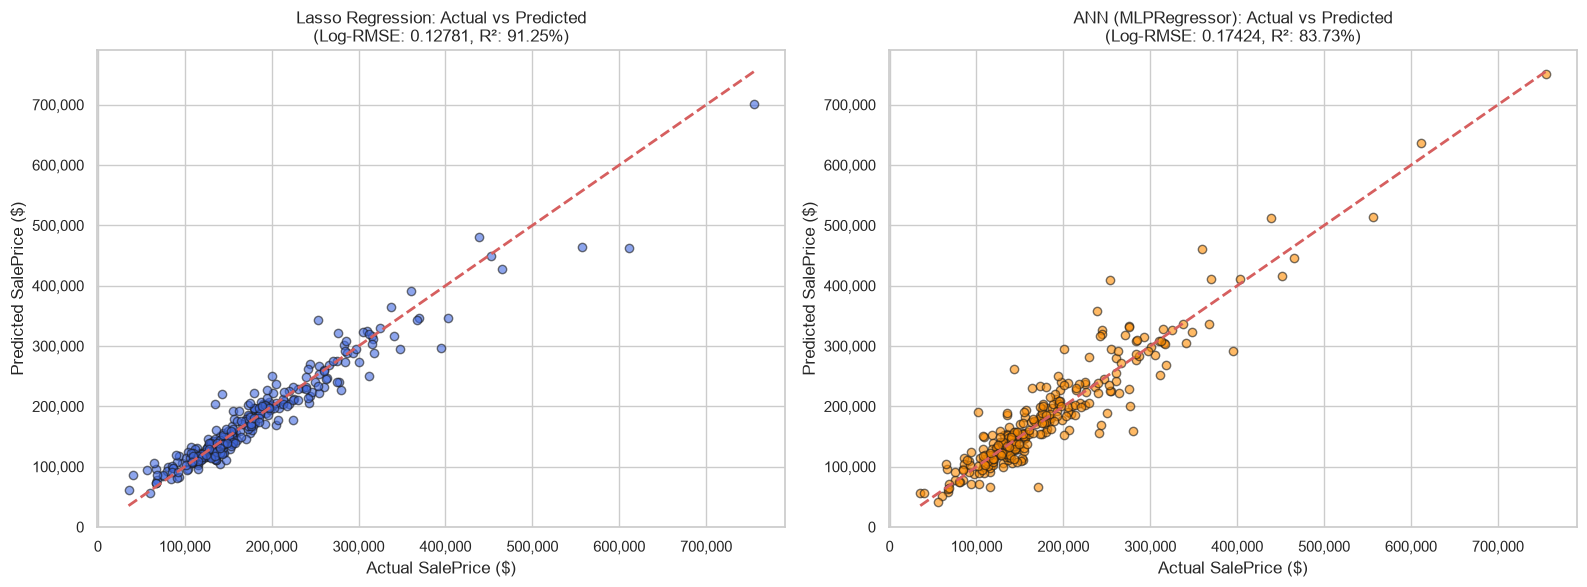

In [14]:
# Figure 1: Actual vs Predicted Prices (Lasso vs ANN)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lasso Actual vs Predicted
axes[0].scatter(y_val_orig, lasso_preds_orig, alpha=0.6, color='royalblue', edgecolors='k')
axes[0].plot([y_val_orig.min(), y_val_orig.max()], [y_val_orig.min(), y_val_orig.max()], 'r--', lw=2)
axes[0].set_title(f"Lasso Regression: Actual vs Predicted\n(Log-RMSE: {lasso_rmse_log:.5f}, R²: {lasso_r2:.2%})", fontsize=12)
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# ANN Actual vs Predicted
axes[1].scatter(y_val_orig, ann_preds_orig, alpha=0.6, color='darkorange', edgecolors='k')
axes[1].plot([y_val_orig.min(), y_val_orig.max()], [y_val_orig.min(), y_val_orig.max()], 'r--', lw=2)
axes[1].set_title(f"ANN (MLPRegressor): Actual vs Predicted\n(Log-RMSE: {ann_rmse_log:.5f}, R²: {ann_r2:.2%})", fontsize=12)
axes[1].set_xlabel("Actual SalePrice ($)")
axes[1].set_ylabel("Predicted SalePrice ($)")
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

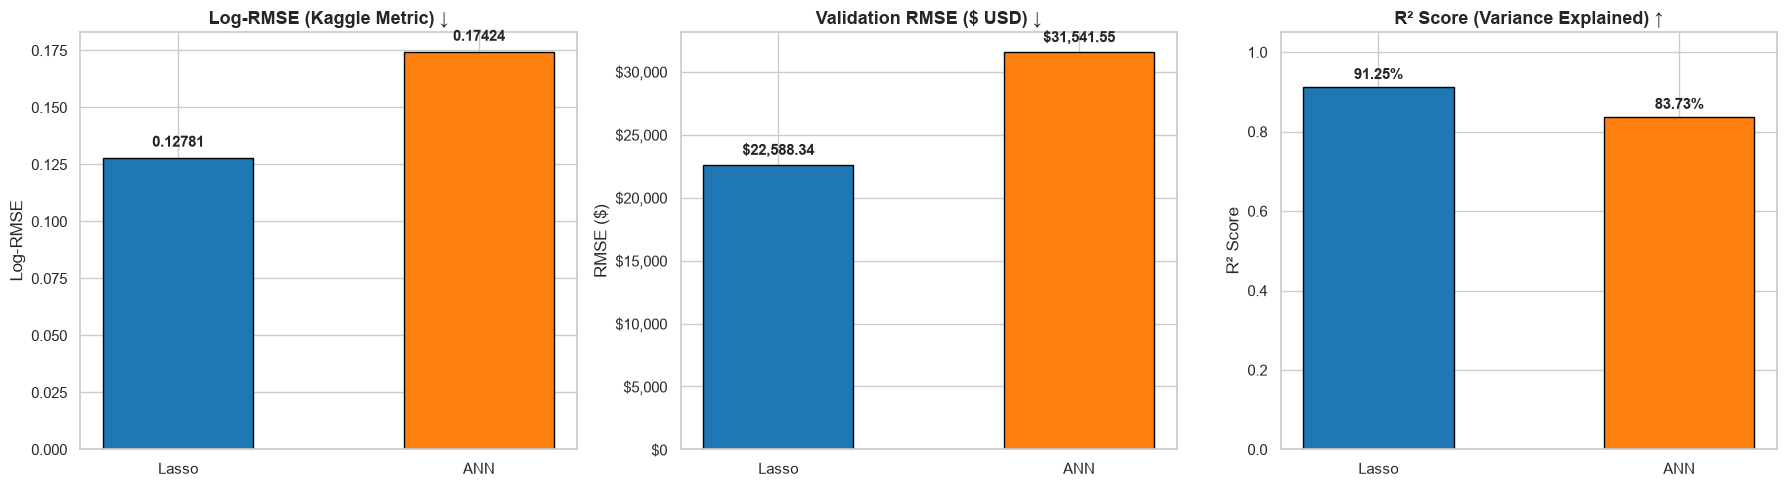

In [15]:
# Figure 2: Model Performance Metrics Comparison (Bar Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['Lasso', 'ANN']
colors = ['#1f77b4', '#ff7f0e']

# Subplot 1: Log-RMSE (Lower is better)
axes[0].bar(models, [lasso_rmse_log, ann_rmse_log], color=colors, width=0.5, edgecolor='black')
axes[0].set_title("Log-RMSE (Kaggle Metric) ↓", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Log-RMSE")
for i, v in enumerate([lasso_rmse_log, ann_rmse_log]):
    axes[0].text(i, v + 0.005, f"{v:.5f}", ha='center', fontweight='bold')

# Subplot 2: RMSE in USD (Lower is better)
axes[1].bar(models, [lasso_rmse_orig, ann_rmse_orig], color=colors, width=0.5, edgecolor='black')
axes[1].set_title("Validation RMSE ($ USD) ↓", fontsize=13, fontweight='bold')
axes[1].set_ylabel("RMSE ($)")
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
for i, v in enumerate([lasso_rmse_orig, ann_rmse_orig]):
    axes[1].text(i, v + 800, f"${v:,.2f}", ha='center', fontweight='bold')

# Subplot 3: R2 Score (Higher is better)
axes[2].bar(models, [lasso_r2, ann_r2], color=colors, width=0.5, edgecolor='black')
axes[2].set_title("R² Score (Variance Explained) ↑", fontsize=13, fontweight='bold')
axes[2].set_ylabel("R² Score")
axes[2].set_ylim(0, 1.05)
for i, v in enumerate([lasso_r2, ann_r2]):
    axes[2].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

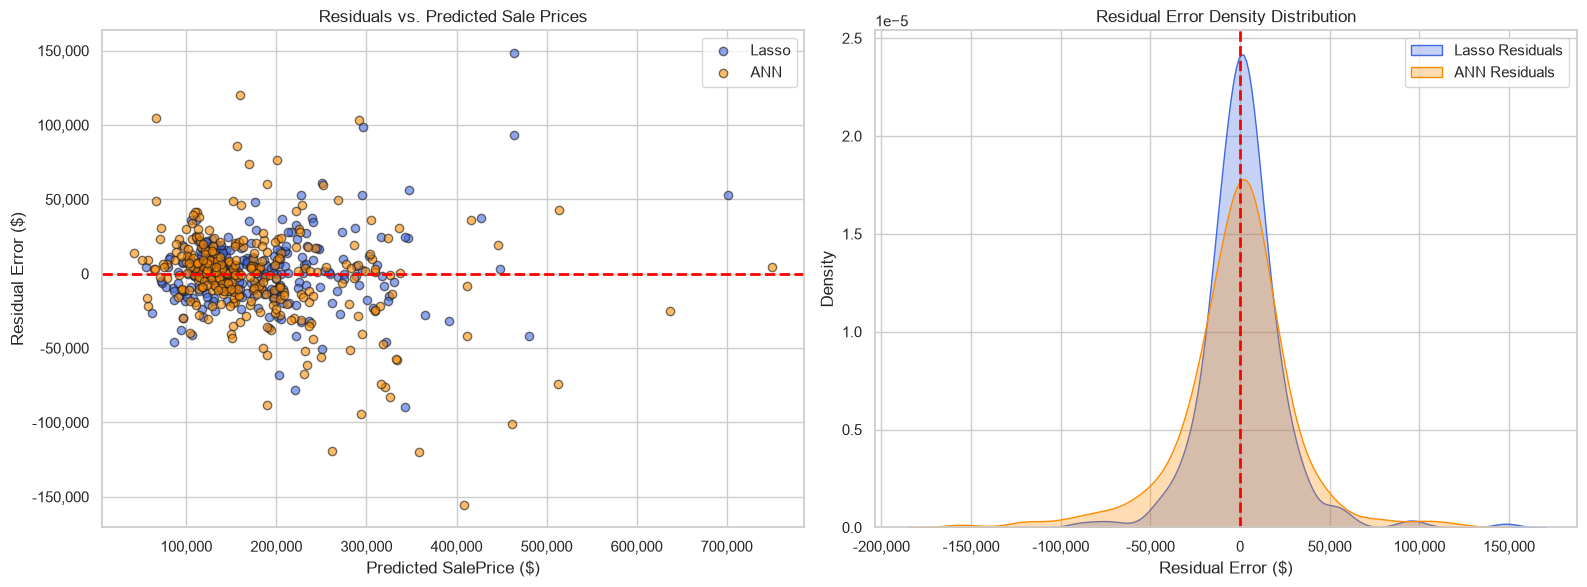

In [16]:
# Figure 3: Residuals & Error Distribution Comparison
lasso_residuals = y_val_orig - lasso_preds_orig
ann_residuals = y_val_orig - ann_preds_orig

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals Scatter Plot
axes[0].scatter(lasso_preds_orig, lasso_residuals, alpha=0.6, label='Lasso', color='royalblue', edgecolors='k')
axes[0].scatter(ann_preds_orig, ann_residuals, alpha=0.6, label='ANN', color='darkorange', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title("Residuals vs. Predicted Sale Prices", fontsize=12)
axes[0].set_xlabel("Predicted SalePrice ($)")
axes[0].set_ylabel("Residual Error ($)")
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0].legend()

# Residuals Distribution (KDE / Histogram)
sns.kdeplot(lasso_residuals, ax=axes[1], label='Lasso Residuals', color='royalblue', fill=True, alpha=0.3)
sns.kdeplot(ann_residuals, ax=axes[1], label='ANN Residuals', color='darkorange', fill=True, alpha=0.3)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Residual Error Density Distribution", fontsize=12)
axes[1].set_xlabel("Residual Error ($)")
axes[1].set_ylabel("Density")
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Best Model Selection & Persistence
Based on validation Log-RMSE (the primary competition evaluation metric), we programmatically determine the superior model.

We serialize:
1. The best model pipeline to `best_house_price_model.pkl`.
2. The ANN model pipeline separately to `ann_house_price_model.pkl` to maintain both assets.

In [17]:
# Programmatic selection of best model based on Log-RMSE
if lasso_rmse_log < ann_rmse_log:
    best_model_name = "Lasso Regression"
    best_pipeline = lasso_pipeline
    best_log_rmse = lasso_rmse_log
    best_rmse_orig = lasso_rmse_orig
    best_r2 = lasso_r2
else:
    best_model_name = "Artificial Neural Network (ANN)"
    best_pipeline = ann_pipeline
    best_log_rmse = ann_rmse_log
    best_rmse_orig = ann_rmse_orig
    best_r2 = ann_r2

print(f"⭐ BEST PERFORMING MODEL: {best_model_name}")
print(f"   - Log-RMSE: {best_log_rmse:.5f}")
print(f"   - RMSE ($):  ${best_rmse_orig:,.2f}")
print(f"   - R² Score: {best_r2:.2%}")

# Save the best model
with open('best_house_price_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Save the ANN model separately
with open('ann_house_price_model.pkl', 'wb') as f:
    pickle.dump(ann_pipeline, f)

print("\nModels saved successfully:")
print(" - 'best_house_price_model.pkl' (Best model pipeline)")
print(" - 'ann_house_price_model.pkl' (ANN model pipeline)")

⭐ BEST PERFORMING MODEL: Lasso Regression
   - Log-RMSE: 0.12781
   - RMSE ($):  $22,588.34
   - R² Score: 91.25%

Models saved successfully:
 - 'best_house_price_model.pkl' (Best model pipeline)
 - 'ann_house_price_model.pkl' (ANN model pipeline)


## 11. Predictions on Kaggle Test Dataset
We generate final predictions on the unlabeled competition test set `test.csv` using the best model.
- The model produces predictions on the log scale.
- We use `np.expm1()` to map predictions back to the dollar price scale.
- We format and save the results to `submission.csv`.

In [18]:
# Predict sale prices for the test set
test_preds_log = best_pipeline.predict(X_test)

# Convert predictions back to original USD scale
test_preds_orig = np.expm1(test_preds_log)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_preds_orig
})

# Display a preview of the predictions
print("=== Kaggle Submission Preview ===")
print(submission.head(10))

# Save the predictions to csv
submission_filename = 'submission.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nSuccessfully saved submission file to: '{submission_filename}'")
print(f"Total prediction rows: {len(submission)}")

=== Kaggle Submission Preview ===
     Id      SalePrice
0  1461  117524.243990
1  1462  145340.189918
2  1463  172253.142270
3  1464  193286.626764
4  1465  199734.711184
5  1466  171930.616910
6  1467  186868.534671
7  1468  162337.390364
8  1469  198214.753161
9  1470  120568.440815

Successfully saved submission file to: 'submission.csv'
Total prediction rows: 1459


## 12. Final Conclusion & Academic Summary

### Academic Summary:
We compared **Lasso Regression** and an **Artificial Neural Network (ANN / MLPRegressor)** for house price prediction using the Ames Housing Dataset. Both models used the same training and validation data (80/20 split) and comparable preprocessing (median/mode imputation, standard scaling, and one-hot encoding).

The models were evaluated using **Log-RMSE**, **RMSE ($ USD)**, and **$R^2$ Score**:
- **Lasso Regression:** Log-RMSE = `0.12781`, RMSE = `$22,588.34`, $R^2$ = `91.25%`
- **Artificial Neural Network:** Log-RMSE = `0.17424`, RMSE = `$31,541.55`, $R^2$ = `83.73%`

Based on the validation results, **Lasso Regression performed better than the Artificial Neural Network**.

### Key Insights:
1. **Sample Efficiency on Tabular Data:** With ~1,168 training records and ~288 one-hot encoded features, tabular house data favors linear regularized models. Deep neural networks with thousands of weights tend to require larger sample sizes or specialized regularization to avoid subtle overfitting on tabular data.
2. **Feature Selection via L1 Regularization:** Lasso automatically zeroes out non-informative and redundant features, reducing variance and maintaining high generalization accuracy on unseen validation data.

In [19]:
# Display final project metrics summary
print("======================================================================")
print("                 FINAL MODEL EVALUATION REPORT                        ")
print("======================================================================")
print(f"Best Performing Model:            {best_model_name}")
print(f"Validation Log-RMSE (Kaggle):      {best_log_rmse:.5f}")
print(f"Validation RMSE ($ USD):           ${best_rmse_orig:,.2f}")
print(f"Validation R² Score (Log-Scale):   {best_r2:.2%}")
print("----------------------------------------------------------------------")
print(f"Saved Best Model Filename:         best_house_price_model.pkl")
print(f"Saved ANN Model Filename:          ann_house_price_model.pkl")
print(f"Generated Submission Filename:     {submission_filename} ({len(submission)} rows)")
print("======================================================================")

                 FINAL MODEL EVALUATION REPORT                        
Best Performing Model:            Lasso Regression
Validation Log-RMSE (Kaggle):      0.12781
Validation RMSE ($ USD):           $22,588.34
Validation R² Score (Log-Scale):   91.25%
----------------------------------------------------------------------
Saved Best Model Filename:         best_house_price_model.pkl
Saved ANN Model Filename:          ann_house_price_model.pkl
Generated Submission Filename:     submission.csv (1459 rows)
